# Предсказание зарплаты программиста по опыту и навыкам
## НИРС по дисциплине «Технологии машинного обучения»

## 1. Поиск и выбор набора данных

В качестве набора данных используется **Stack Overflow Developer Survey 2024** — ежегодный опрос разработчиков программного обеспечения, проводимый платформой Stack Overflow. Датасет содержит **65 437 записей** и охватывает специалистов из более чем 180 стран.

Источник: https://github.com/StackExchange/Survey (открытые данные)

**Задача:** регрессия — предсказание годовой зарплаты в USD (целевой признак `ConvertedCompYearly`).

После фильтрации (зарплата 10 000–500 000 USD, только строки с заполненной зарплатой) из 65 437 записей осталось **20 907**.

### Описание используемых признаков:

| Признак | Описание | Кодирование |
|---------|----------|-------------|
| `YearsCodePro_n` | Лет профессионального опыта программирования | числовой |
| `YearsCode_n` | Лет программирования в целом (включая учёбу) | числовой |
| `WorkExp_n` | Лет общего рабочего опыта | числовой |
| `EdLevel_n` | Уровень образования | порядковый (1–8) |
| `OrgSize_n` | Размер организации по числу сотрудников | порядковый (1–9) |
| `Remote_n` | Формат работы: Remote / Hybrid / In-person | порядковый (0–2) |
| `Country_n` | Страна (топ-10 + «Other») | LabelEncoder |
| `DevType_n` | Основной тип разработчика | числовой (0–10) |
| `lang_count` | Количество языков программирования в стеке | числовой |
| `lang_Python`, `lang_JavaScript`, … `lang_Rust` | Наличие языка в стеке (топ-10) | бинарный (0/1) |
| `IsFullTime` | Флаг полной занятости | бинарный (0/1) |

Датасет разбит на три файла:
- `datatraining.csv` — обучающая выборка (10 000 записей)
- `datatest.csv` — тестовая выборка (3 000 записей)
- `datatest2.csv` — тестовая выборка большего размера (7 907 записей)

### Импорт библиотек

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

matplotlib.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)
print('Libraries loaded.')

Libraries loaded.


## 2. Загрузка и первичный анализ данных

In [36]:
df_raw = pd.read_csv('data/survey_results_public.csv')
print(f'Размер датасета: {df_raw.shape}')
print(f'Колонок: {df_raw.shape[1]}')
df_raw[['YearsCodePro', 'EdLevel', 'Country', 'DevType', 'ConvertedCompYearly', 'LanguageHaveWorkedWith']].head(5)

Размер датасета: (65437, 114)
Колонок: 114


,YearsCodePro,EdLevel,Country,DevType,ConvertedCompYearly,LanguageHaveWorkedWith
0,NaN,Primary/elementary school,United States of America,NaN,NaN,NaN
1,17,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",United Kingdom of Great Britain and Northern I...,"Developer, full-stack",NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2,27,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",United Kingdom of Great Britain and Northern I...,Developer Experience,NaN,C#
3,NaN,Some college/university study without earning ...,Canada,"Developer, full-stack",NaN,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...
4,NaN,"Secondary school (e.g. American high school, G...",Norway,"Developer, full-stack",NaN,C++;HTML/CSS;JavaScript;Lua;Python;Rust


In [37]:
# Целевая переменная — ConvertedCompYearly (годовая зарплата в USD)
print('Наличие зарплаты (не NaN):', df_raw['ConvertedCompYearly'].notna().sum())
print('Пропуски зарплаты:', df_raw['ConvertedCompYearly'].isna().sum())
print()
print('Описательная статистика зарплаты:')
df_raw['ConvertedCompYearly'].describe()

Наличие зарплаты (не NaN): 23435
Пропуски зарплаты: 42002

Описательная статистика зарплаты:


count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

## 3. Разведочный анализ данных (EDA)

In [38]:
df = df_raw[df_raw['ConvertedCompYearly'].notna()].copy()
df = df[(df['ConvertedCompYearly'] >= 10_000) & (df['ConvertedCompYearly'] <= 500_000)].copy()
print(f'Строк после фильтрации зарплаты (10k–500k USD): {len(df)}')

Строк после фильтрации зарплаты (10k–500k USD): 20907


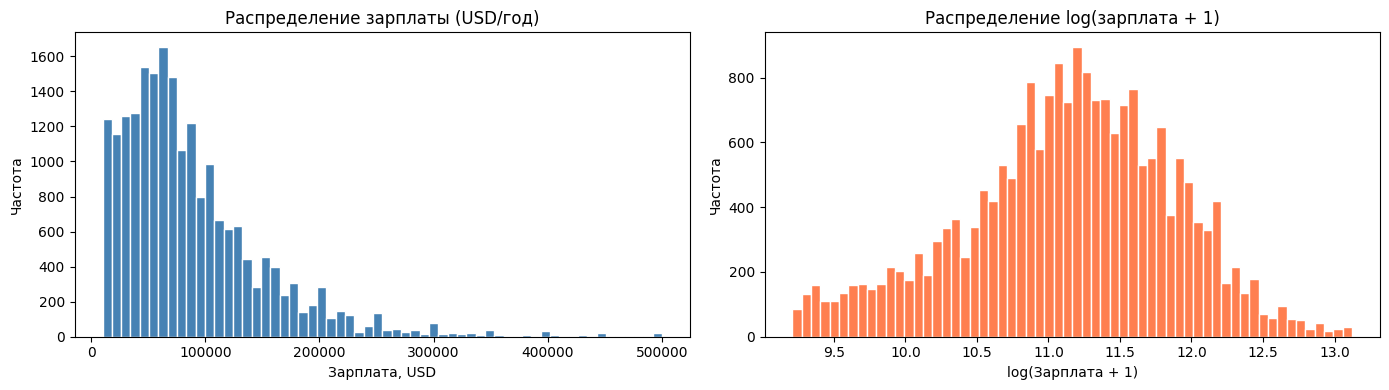

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['ConvertedCompYearly'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение зарплаты (USD/год)')
axes[0].set_xlabel('Зарплата, USD')
axes[0].set_ylabel('Частота')

axes[1].hist(np.log1p(df['ConvertedCompYearly']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Распределение log(зарплата + 1)')
axes[1].set_xlabel('log(Зарплата + 1)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

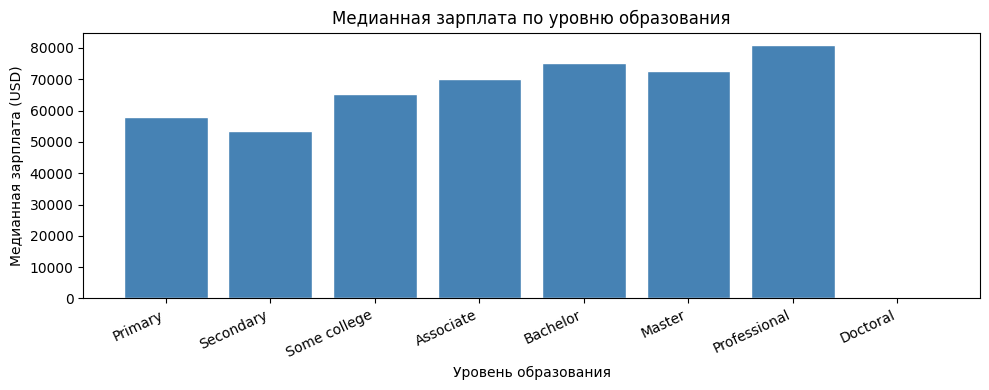

In [40]:
# Уровень образования vs зарплата
ed_order = [
    'Primary/elementary school',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
    'Some college/university study without earning a degree',
    'Associate degree (A.A., A.S., etc.)',
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
    'Other doctoral degree (Ph.D., Ed.D., etc.)',
]
ed_labels = ['Primary', 'Secondary', 'Some college', 'Associate', 'Bachelor', 'Master', 'Professional', 'Doctoral']

ed_salary = []
for ed in ed_order:
    vals = df[df['EdLevel'] == ed]['ConvertedCompYearly'].dropna()
    if len(vals) > 0:
        ed_salary.append(vals.median())
    else:
        ed_salary.append(0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ed_labels, ed_salary, color='steelblue', edgecolor='white')
ax.set_title('Медианная зарплата по уровню образования')
ax.set_xlabel('Уровень образования')
ax.set_ylabel('Медианная зарплата (USD)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

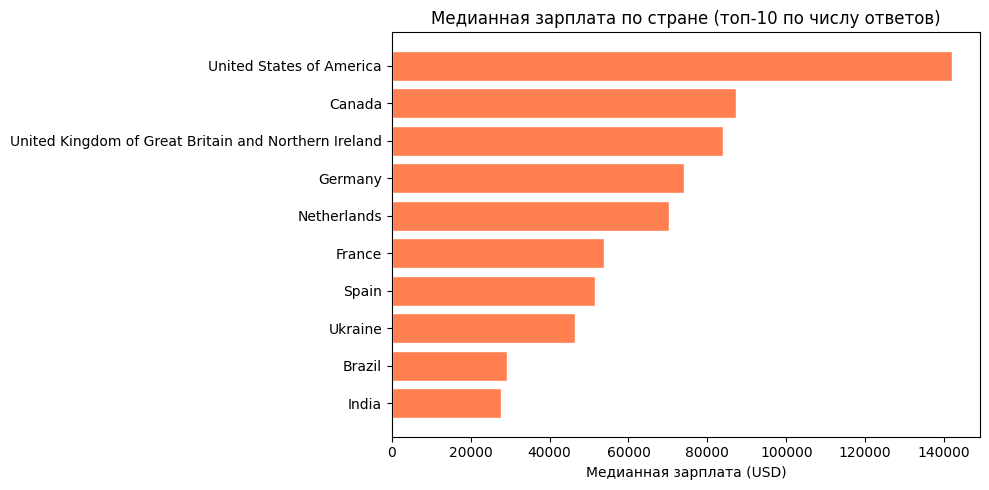

In [41]:
# Топ-10 стран по медианной зарплате
top_countries = df['Country'].value_counts().head(10).index
df_top = df[df['Country'].isin(top_countries)]
country_med = df_top.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(country_med.index, country_med.values, color='coral', edgecolor='white')
ax.set_title('Медианная зарплата по стране (топ-10 по числу ответов)')
ax.set_xlabel('Медианная зарплата (USD)')
plt.tight_layout()
plt.show()

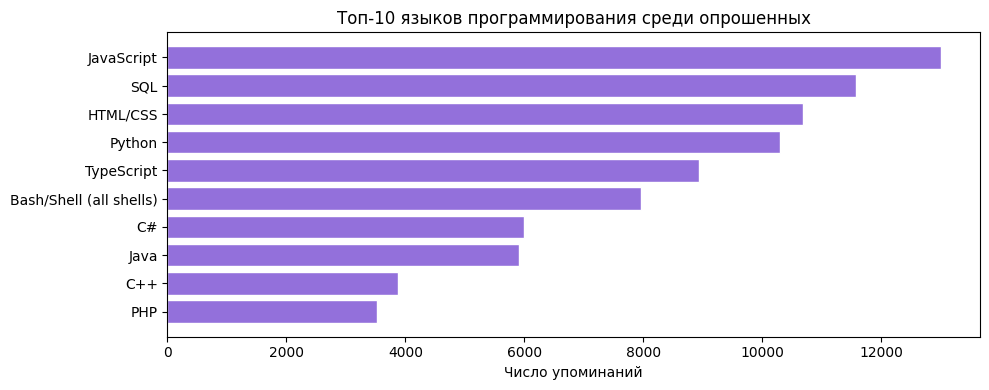

In [42]:
# Топ-10 языков программирования
langs_all = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
top_langs_df = langs_all.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_langs_df.index[::-1], top_langs_df.values[::-1], color='mediumpurple', edgecolor='white')
ax.set_title('Топ-10 языков программирования среди опрошенных')
ax.set_xlabel('Число упоминаний')
plt.tight_layout()
plt.show()

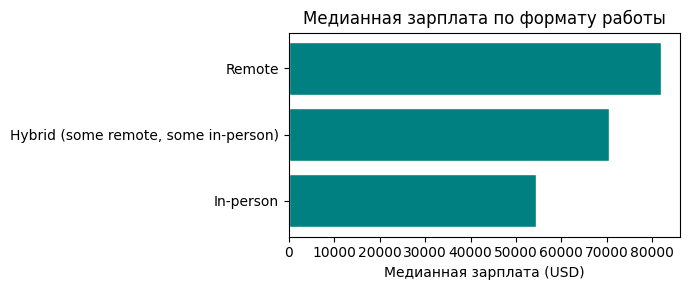

In [43]:
# Зарплата по типу занятости (remote/hybrid/office)
remote_salary = df.groupby('RemoteWork')['ConvertedCompYearly'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(remote_salary.index, remote_salary.values, color='teal', edgecolor='white')
ax.set_title('Медианная зарплата по формату работы')
ax.set_xlabel('Медианная зарплата (USD)')
plt.tight_layout()
plt.show()

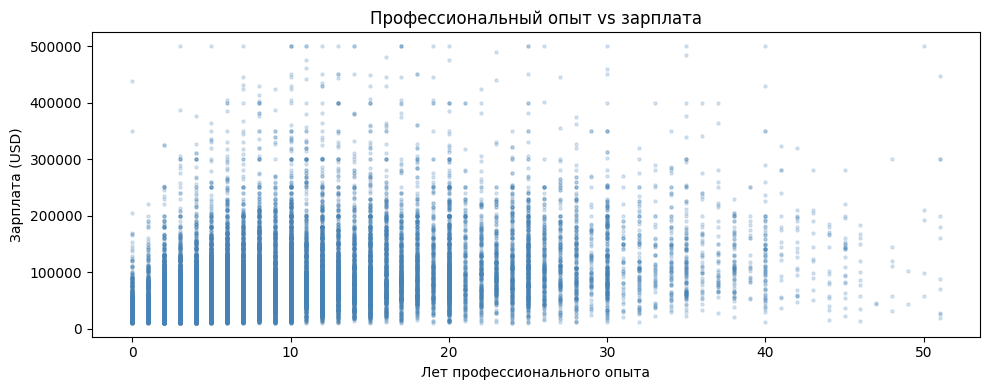

In [44]:
# Опыт работы vs зарплата
def clean_years(val):
    if pd.isna(val): return np.nan
    if str(val) == 'Less than 1 year': return 0.0
    if str(val) == 'More than 50 years': return 51.0
    try: return float(val)
    except: return np.nan

df['YearsCodePro_n'] = df['YearsCodePro'].apply(clean_years)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df['YearsCodePro_n'], df['ConvertedCompYearly'], alpha=0.2, s=5, color='steelblue')
ax.set_title('Профессиональный опыт vs зарплата')
ax.set_xlabel('Лет профессионального опыта')
ax.set_ylabel('Зарплата (USD)')
plt.tight_layout()
plt.show()

## 4. Предобработка и конструирование признаков

In [45]:
# ── Числовые признаки: опыт ──────────────────────────────────────────────
df['YearsCode_n']    = df['YearsCode'].apply(clean_years)
df['YearsCodePro_n'] = df['YearsCodePro'].apply(clean_years)  # уже создан выше
df['WorkExp_n']      = df['WorkExp'].apply(clean_years)

# Заполняем пропуски медианой (не удаляем строки)
for col in ['YearsCode_n', 'YearsCodePro_n', 'WorkExp_n']:
    df[col] = df[col].fillna(df[col].median())

print('YearsCodePro_n stats:')
print(df['YearsCodePro_n'].describe())

YearsCodePro_n stats:
count    20907.000000
mean        10.780695
std          8.715629
min          0.000000
25%          4.000000
50%          8.000000
75%         15.000000
max         51.000000
Name: YearsCodePro_n, dtype: float64


In [46]:
# ── Уровень образования: порядковое кодирование ─────────────────────────
ed_map = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": 5,
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7,
    'Other doctoral degree (Ph.D., Ed.D., etc.)': 8,
}
df['EdLevel_n'] = df['EdLevel'].map(ed_map).fillna(3)  # нет данных → 'Some college'
print('EdLevel_n value_counts:')
print(df['EdLevel_n'].value_counts().sort_index())

EdLevel_n value_counts:
EdLevel_n
1.0     108
2.0     996
3.0    2651
4.0     655
5.0    9153
6.0    6254
7.0    1090
Name: count, dtype: int64


In [47]:
# ── Размер компании: порядковое кодирование ─────────────────────────────
org_map = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    '2 to 9 employees': 2,
    '10 to 19 employees': 3,
    '20 to 99 employees': 4,
    '100 to 499 employees': 5,
    '500 to 999 employees': 6,
    '1,000 to 4,999 employees': 7,
    '5,000 to 9,999 employees': 8,
    '10,000 or more employees': 9,
}
df['OrgSize_n'] = df['OrgSize'].map(org_map).fillna(4)

# ── Формат работы ──────────────────────────────────────────────────────
remote_map = {'Remote': 0, 'Hybrid (some remote, some in-person)': 1, 'In-person': 2}
df['Remote_n'] = df['RemoteWork'].map(remote_map).fillna(1)

In [48]:
# ── Страна: топ-10 + 'Other', LabelEncoder ──────────────────────────────
top_countries_list = df['Country'].value_counts().head(10).index.tolist()
df['Country_grp'] = df['Country'].apply(lambda x: x if x in top_countries_list else 'Other')
le_country = LabelEncoder()
df['Country_n'] = le_country.fit_transform(df['Country_grp'].fillna('Other'))
print('Country classes:', le_country.classes_)

Country classes: ['Brazil' 'Canada' 'France' 'Germany' 'India' 'Netherlands' 'Other'
 'Spain' 'Ukraine' 'United Kingdom of Great Britain and Northern Ireland'
 'United States of America']


In [49]:
# ── Языки программирования: бинарные признаки для топ-10 ───────────────
top_langs = ['Python', 'JavaScript', 'TypeScript', 'SQL', 'Java', 'C#', 'C++', 'PHP', 'Go', 'Rust']
for lang in top_langs:
    col = lang.replace('/', '_').replace('#', 'Sharp').replace('+', 'Plus')
    # Точное совпадение через split — избегаем 'Java' ⊂ 'JavaScript'
    df[f'lang_{col}'] = df['LanguageHaveWorkedWith'].fillna('').apply(
        lambda x, l=lang: int(l in x.split(';')))

# Количество языков как отдельный признак
df['lang_count'] = df['LanguageHaveWorkedWith'].fillna('').apply(
    lambda x: len(x.split(';')) if x else 0)
print('Средний lang_count:', df['lang_count'].mean().round(2))

Средний lang_count: 5.31


In [50]:
# ── Тип разработчика (первичная роль) ──────────────────────────────────
devtype_map = {
    'Developer, full-stack': 0,
    'Developer, back-end': 1,
    'Developer, front-end': 2,
    'Data scientist or machine learning specialist': 3,
    'Data engineer': 4,
    'DevOps specialist': 5,
    'Engineering manager': 6,
    'Developer, mobile': 7,
    'Developer, desktop or enterprise applications': 8,
    'Developer, embedded applications or devices': 9,
}
df['DevType_primary'] = df['DevType'].fillna('').apply(lambda x: x.split(';')[0].strip() if x else '')
df['DevType_n'] = df['DevType_primary'].map(devtype_map).fillna(10)  # 10 = Other

# Флаг полной занятости
df['IsFullTime'] = df['Employment'].fillna('').str.contains('Employed, full-time').astype(int)

print('Предобработка завершена.')

Предобработка завершена.


In [51]:
feature_cols = [
    'YearsCodePro_n', 'YearsCode_n', 'WorkExp_n',
    'EdLevel_n', 'OrgSize_n', 'Remote_n', 'Country_n', 'DevType_n',
    'lang_count', 'lang_Python', 'lang_JavaScript', 'lang_TypeScript',
    'lang_SQL', 'lang_Java', 'lang_CSharp', 'lang_CPlusPlus',
    'lang_PHP', 'lang_Go', 'lang_Rust', 'IsFullTime'
]
target_col = 'ConvertedCompYearly'

df_model = df[feature_cols + [target_col]].copy()
print(f'Строк для моделирования: {len(df_model)}')
print(f'Признаков: {len(feature_cols)}')
df_model[feature_cols].describe()

Строк для моделирования: 20907
Признаков: 20


,YearsCodePro_n,YearsCode_n,WorkExp_n,EdLevel_n,OrgSize_n,Remote_n,Country_n,DevType_n,lang_count,lang_Python,lang_JavaScript,lang_TypeScript,lang_SQL,lang_Java,lang_CSharp,lang_CPlusPlus,lang_PHP,lang_Go,lang_Rust,IsFullTime
count,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000,20907.000000
mean,10.780695,15.802267,11.162386,4.954895,5.136127,0.744679,6.280863,3.490649,5.310518,0.492658,0.622423,0.427178,0.553642,0.282346,0.286746,0.185249,0.168173,0.151576,0.129000,0.878557
std,8.715629,9.940641,7.486452,1.247258,2.216393,0.706162,2.811403,4.016117,2.988579,0.499958,0.484793,0.494680,0.497126,0.450151,0.452253,0.388509,0.374029,0.358618,0.335208,0.326649
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,8.000000,7.000000,5.000000,4.000000,0.000000,5.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,8.000000,13.000000,10.000000,5.000000,5.000000,1.000000,6.000000,1.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,15.000000,20.000000,12.000000,6.000000,7.000000,1.000000,9.000000,8.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,51.000000,51.000000,50.000000,7.000000,9.000000,2.000000,10.000000,10.000000,32.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 5. Корреляционный анализ

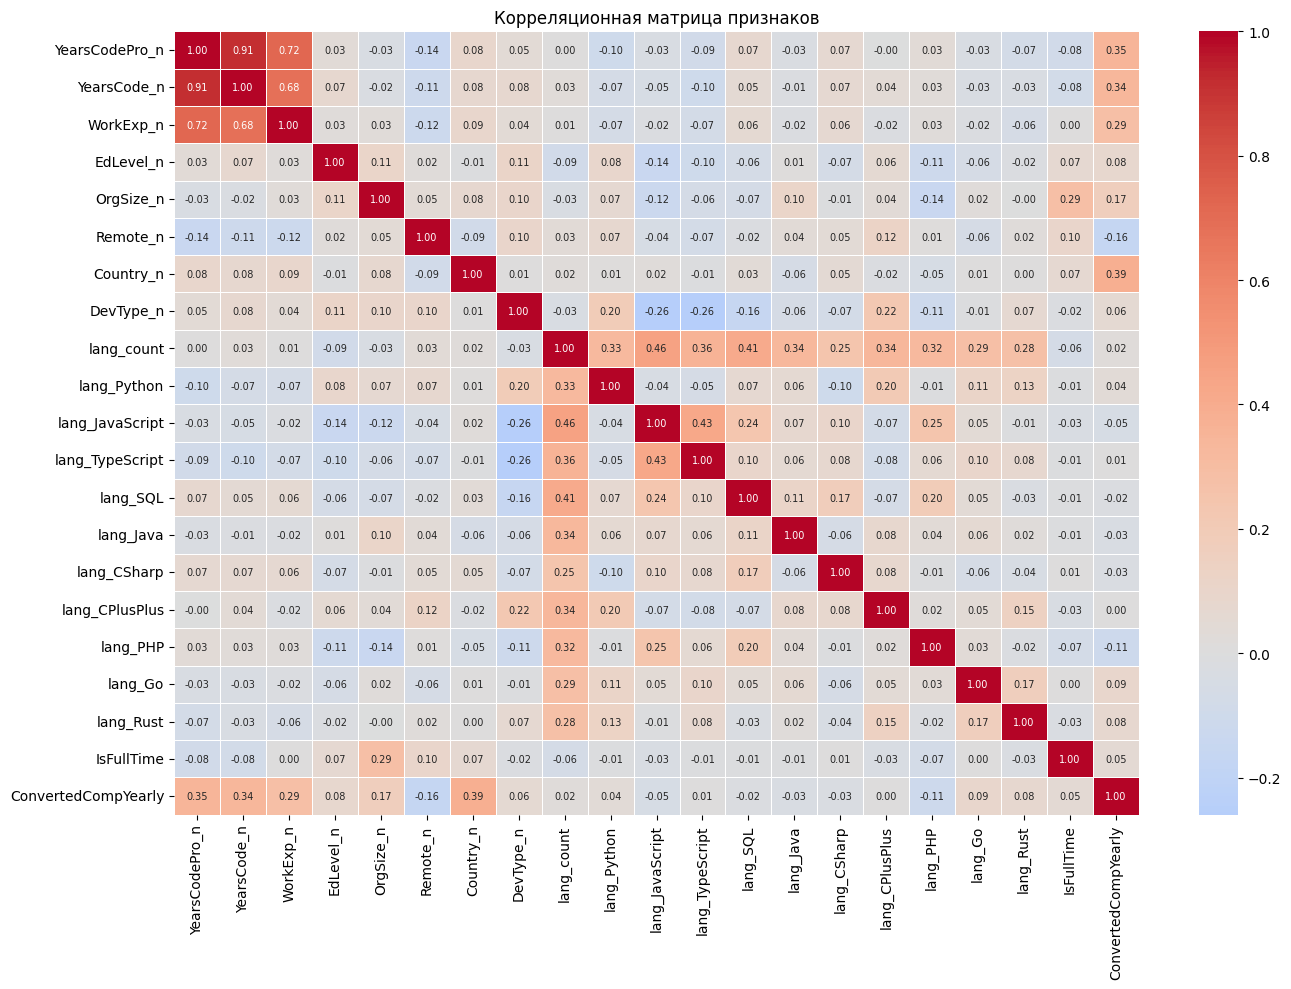

In [52]:
corr = df_model[feature_cols + [target_col]].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

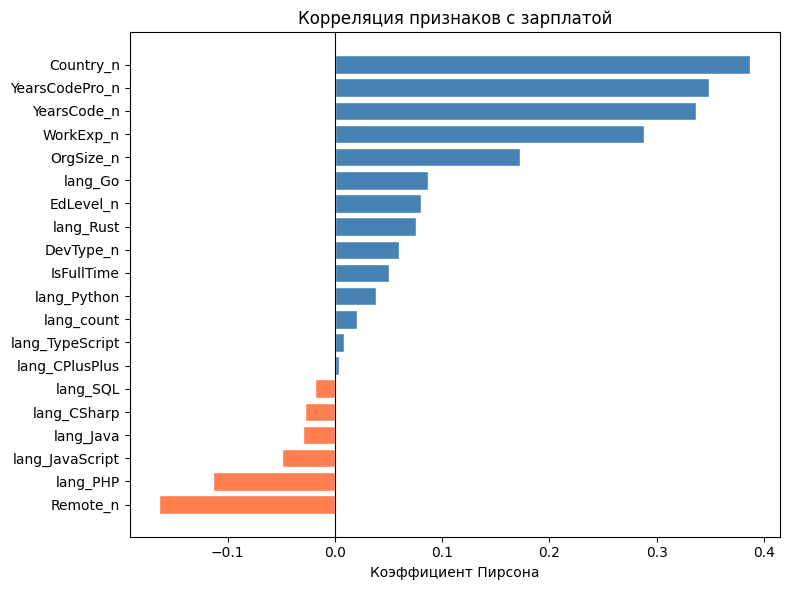

Признаки с наибольшей корреляцией:
Country_n         0.387367
YearsCodePro_n    0.348298
YearsCode_n       0.336922
WorkExp_n         0.288503
OrgSize_n         0.172926
Remote_n          0.163823
lang_PHP          0.113680
lang_Go           0.086422
Name: ConvertedCompYearly, dtype: float64


In [53]:
# Корреляция каждого признака с целевой переменной
corr_target = df_model.corr()[target_col].drop(target_col).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if v < 0 else 'steelblue' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Корреляция признаков с зарплатой')
ax.set_xlabel('Коэффициент Пирсона')
plt.tight_layout()
plt.show()

print('Признаки с наибольшей корреляцией:')
print(corr_target.abs().sort_values(ascending=False).head(8))

### Промежуточные выводы по корреляционному анализу

- **Country_n** имеет наибольшую корреляцию с зарплатой (r≈0.39) — различия в уровне оплаты труда между странами очень велики.
- **YearsCodePro_n** и **WorkExp_n** занимают 2-е и 3-е места по корреляции — опыт является ключевым числовым фактором.
- **OrgSize_n** умеренно коррелирует с зарплатой — крупные компании платят больше.
- Бинарные признаки языков (Python, TypeScript, Go) имеют слабую, но положительную корреляцию.
- Отсутствие мультиколлинеарности критичного уровня подтверждает возможность построения линейных и нелинейных моделей.

## 6. Выбор метрик оценки качества

Для оценки регрессионных моделей выбраны четыре метрики:

| Метрика | Формула | Интерпретация |
|---------|---------|---------------|
| **MAE** | mean(|y - ŷ|) | Средняя абсолютная ошибка в USD |
| **RMSE** | sqrt(mean((y - ŷ)²)) | Штрафует крупные ошибки сильнее |
| **R²** | 1 − SS_res/SS_tot | Доля объяснённой дисперсии (1 = идеал) |
| **MAPE** | mean(|y − ŷ| / y) × 100 | Относительная ошибка в % |

**Обоснование:** MAE и MAPE интерпретируемы в единицах задачи; RMSE акцентирует крупные ошибки;
R² позволяет сравнивать модели независимо от масштаба данных.

In [54]:
def evaluate(y_true, y_pred, name='Model'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:35s} MAE={mae:8.0f}  RMSE={rmse:8.0f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return dict(Model=name, MAE=round(mae,1), RMSE=round(rmse,1), R2=round(r2,4), MAPE=round(mape,2))

## 7. Формирование обучающей и тестовых выборок

In [55]:
train = pd.read_csv('data/datatraining.csv')
test1 = pd.read_csv('data/datatest.csv')
test2 = pd.read_csv('data/datatest2.csv')

print(f'Train:  {len(train):>6} строк')
print(f'Test1:  {len(test1):>6} строк')
print(f'Test2:  {len(test2):>6} строк')

X_train = train[feature_cols].values
y_train = train[target_col].values
X_test  = test1[feature_cols].values
y_test  = test1[target_col].values

# Масштабирование: fit на train, transform на test
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(train[feature_cols])
X_test_sc  = scaler.transform(test1[feature_cols])
X_test2_sc = scaler.transform(test2[feature_cols])
y_test2    = test2[target_col].values

print('Масштабирование применено.')

Train:   10000 строк
Test1:    3000 строк
Test2:    7907 строк
Масштабирование применено.


## 8. Базовые модели (Baseline)

Все модели обучаются с параметрами по умолчанию. Оценка производится на **Test1** (3 000 строк).

In [56]:
baseline_models = {
    'LinearRegression':      LinearRegression(),
    'Ridge (alpha=1)':       Ridge(random_state=42),
    'KNeighborsRegressor':   KNeighborsRegressor(),
    'DecisionTree':          DecisionTreeRegressor(random_state=42),
    'RandomForest':          RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting':      GradientBoostingRegressor(random_state=42),
}

baseline_results = []
for name, model in baseline_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    baseline_results.append(evaluate(y_test, y_pred, name))

baseline_df = pd.DataFrame(baseline_results)
print()
baseline_df.sort_values('R2', ascending=False)

LinearRegression                    MAE=   38284  RMSE=   54573  R²=0.3169  MAPE=69.39%
Ridge (alpha=1)                     MAE=   38282  RMSE=   54575  R²=0.3169  MAPE=69.40%
KNeighborsRegressor                 MAE=   41555  RMSE=   60033  R²=0.1734  MAPE=74.49%
DecisionTree                        MAE=   45404  RMSE=   68315  R²=-0.0704  MAPE=69.25%
RandomForest                        MAE=   31950  RMSE=   47919  R²=0.4733  MAPE=53.17%
GradientBoosting                    MAE=   30965  RMSE=   46966  R²=0.4941  MAPE=50.77%



,Model,MAE,RMSE,R2,MAPE
5,GradientBoosting,30965.1,46965.8,0.4941,50.77
4,RandomForest,31949.6,47918.8,0.4733,53.17
0,LinearRegression,38283.7,54573.0,0.3169,69.39
1,Ridge (alpha=1),38282.2,54574.7,0.3169,69.40
2,KNeighborsRegressor,41554.7,60032.8,0.1734,74.49
3,DecisionTree,45403.8,68315.4,-0.0704,69.25


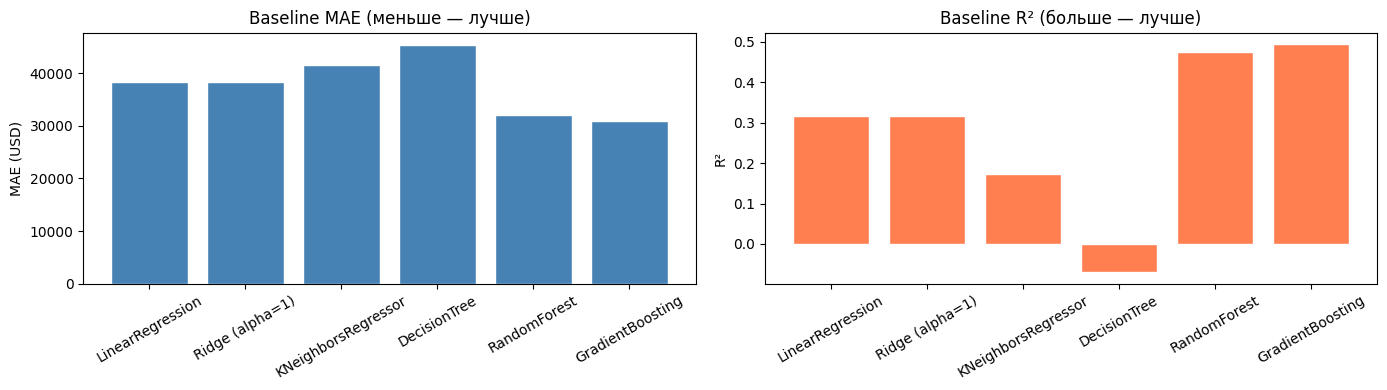

In [57]:
# Визуализация baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(baseline_df['Model'], baseline_df['MAE'], color='steelblue', edgecolor='white')
axes[0].set_title('Baseline MAE (меньше — лучше)')
axes[0].set_ylabel('MAE (USD)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(baseline_df['Model'], baseline_df['R2'], color='coral', edgecolor='white')
axes[1].set_title('Baseline R² (больше — лучше)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 9. Подбор гиперпараметров (GridSearchCV)

In [58]:
# Ridge
ridge_gs = GridSearchCV(
    Ridge(), {'alpha': [0.1, 1, 10, 50, 100, 500]},
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
ridge_gs.fit(X_train_sc, y_train)
print('Ridge best:', ridge_gs.best_params_)

Ridge best: {'alpha': 50}


In [59]:
# KNeighbors
knn_gs = GridSearchCV(
    KNeighborsRegressor(),
    {'n_neighbors': [3, 5, 7, 10, 15, 20], 'weights': ['uniform', 'distance']},
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
knn_gs.fit(X_train_sc, y_train)
print('KNN best:', knn_gs.best_params_)

KNN best: {'n_neighbors': 20, 'weights': 'distance'}


In [60]:
# DecisionTree
dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [5, 8, 10, 15, 20, None], 'min_samples_split': [2, 5, 10]},
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
dt_gs.fit(X_train_sc, y_train)
print('DecisionTree best:', dt_gs.best_params_)

DecisionTree best: {'max_depth': 5, 'min_samples_split': 2}


In [61]:
# RandomForest
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 15, 20, None]},
    cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
)
rf_gs.fit(X_train_sc, y_train)
print('RandomForest best:', rf_gs.best_params_)

RandomForest best: {'max_depth': 10, 'n_estimators': 200}


In [62]:
# GradientBoosting
gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
    },
    cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
)
gb_gs.fit(X_train_sc, y_train)
print('GradientBoosting best:', gb_gs.best_params_)

GradientBoosting best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


## 10. Сравнение baseline и tuned-моделей

In [63]:
tuned_models = {
    'LinearRegression':       LinearRegression(),
    'Ridge (tuned)':          Ridge(**ridge_gs.best_params_),
    'KNN (tuned)':            knn_gs.best_estimator_,
    'DecisionTree (tuned)':   dt_gs.best_estimator_,
    'RandomForest (tuned)':   rf_gs.best_estimator_,
    'GradientBoosting (tuned)': gb_gs.best_estimator_,
}

tuned_results = []
for name, model in tuned_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    tuned_results.append(evaluate(y_test, y_pred, name))

tuned_df = pd.DataFrame(tuned_results)
print()
tuned_df.sort_values('R2', ascending=False)

LinearRegression                    MAE=   38284  RMSE=   54573  R²=0.3169  MAPE=69.39%
Ridge (tuned)                       MAE=   38218  RMSE=   54664  R²=0.3146  MAPE=69.79%
KNN (tuned)                         MAE=   39633  RMSE=   58038  R²=0.2274  MAPE=72.49%
DecisionTree (tuned)                MAE=   33499  RMSE=   49775  R²=0.4317  MAPE=57.49%
RandomForest (tuned)                MAE=   31418  RMSE=   47501  R²=0.4825  MAPE=52.26%
GradientBoosting (tuned)            MAE=   30709  RMSE=   46696  R²=0.4999  MAPE=49.21%



,Model,MAE,RMSE,R2,MAPE
5,GradientBoosting (tuned),30708.8,46696.4,0.4999,49.21
4,RandomForest (tuned),31418.4,47501.3,0.4825,52.26
3,DecisionTree (tuned),33498.9,49775.0,0.4317,57.49
0,LinearRegression,38283.7,54573.0,0.3169,69.39
1,Ridge (tuned),38217.6,54664.5,0.3146,69.79
2,KNN (tuned),39632.5,58037.6,0.2274,72.49


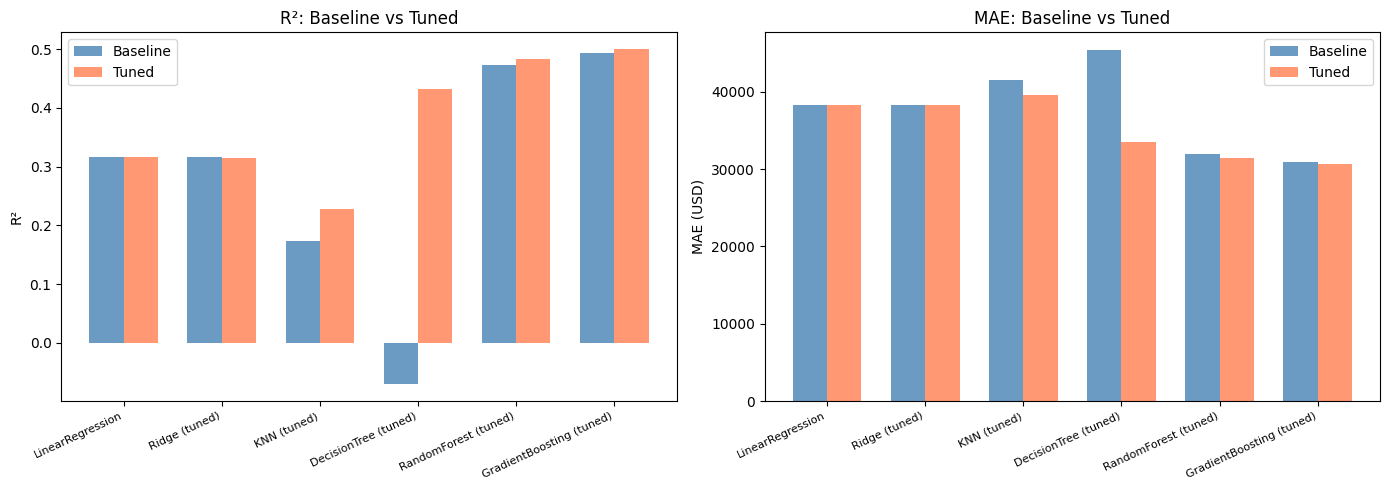

In [64]:
# Сравнительный график: baseline vs tuned
compare_names = ['LinearRegression', 'Ridge', 'KNN', 'DecisionTree', 'RandomForest', 'GradientBoosting']
bl_r2   = baseline_df.set_index('Model')['R2']
tun_r2  = tuned_df.set_index('Model')['R2']

bl_mae  = baseline_df.set_index('Model')['MAE']
tun_mae = tuned_df.set_index('Model')['MAE']

x = np.arange(len(tuned_df))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R²
axes[0].bar(x - w/2, baseline_df['R2'], w, label='Baseline', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, tuned_df['R2'],    w, label='Tuned',    color='coral',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tuned_df['Model'], rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('R²')
axes[0].set_title('R²: Baseline vs Tuned')
axes[0].legend()

# MAE
axes[1].bar(x - w/2, baseline_df['MAE'], w, label='Baseline', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, tuned_df['MAE'],    w, label='Tuned',    color='coral',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(tuned_df['Model'], rotation=25, ha='right', fontsize=8)
axes[1].set_ylabel('MAE (USD)')
axes[1].set_title('MAE: Baseline vs Tuned')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Анализ лучшей модели

In [65]:
best_model = gb_gs.best_estimator_
y_pred_best = best_model.predict(X_test_sc)

print('=== Лучшая модель: GradientBoosting (tuned) ===')
res = evaluate(y_test, y_pred_best, 'GradientBoosting (tuned)')

# На Test2
y_pred_test2 = best_model.predict(X_test2_sc)
print()
print('=== На Test2 (7 907 строк) ===')
evaluate(y_test2, y_pred_test2, 'GradientBoosting (tuned) [Test2]')

=== Лучшая модель: GradientBoosting (tuned) ===
GradientBoosting (tuned)            MAE=   30709  RMSE=   46696  R²=0.4999  MAPE=49.21%

=== На Test2 (7 907 строк) ===
GradientBoosting (tuned) [Test2]    MAE=   30617  RMSE=   47055  R²=0.4851  MAPE=50.87%


{'Model': 'GradientBoosting (tuned) [Test2]',
 'MAE': 30617.2,
 'RMSE': np.float64(47055.0),
 'R2': 0.4851,
 'MAPE': np.float64(50.87)}

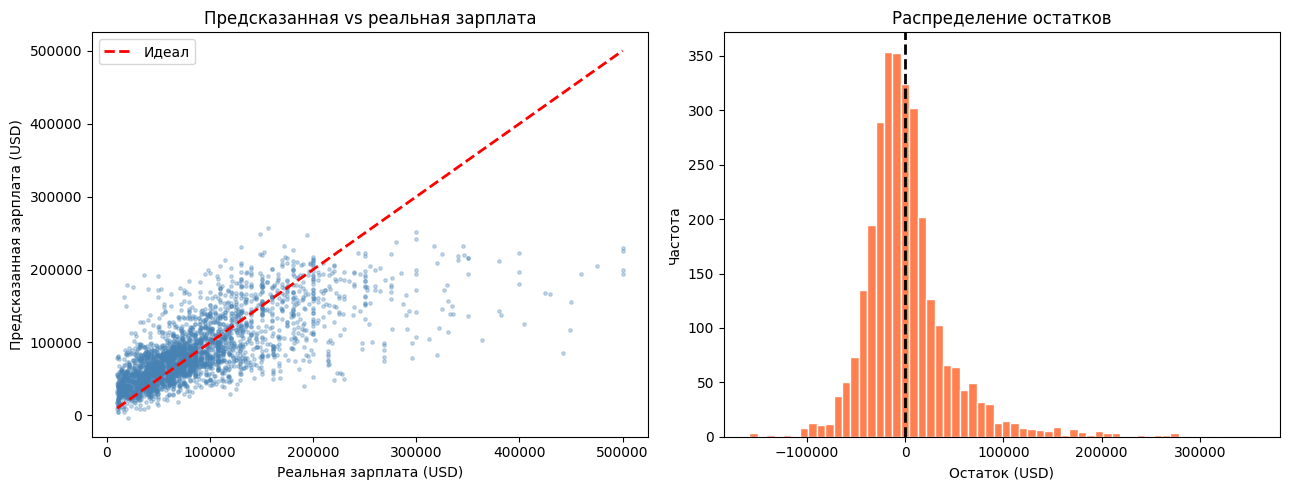

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=6, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Идеал')
axes[0].set_xlabel('Реальная зарплата (USD)')
axes[0].set_ylabel('Предсказанная зарплата (USD)')
axes[0].set_title('Предсказанная vs реальная зарплата')
axes[0].legend()

# Residuals distribution
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Остаток (USD)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

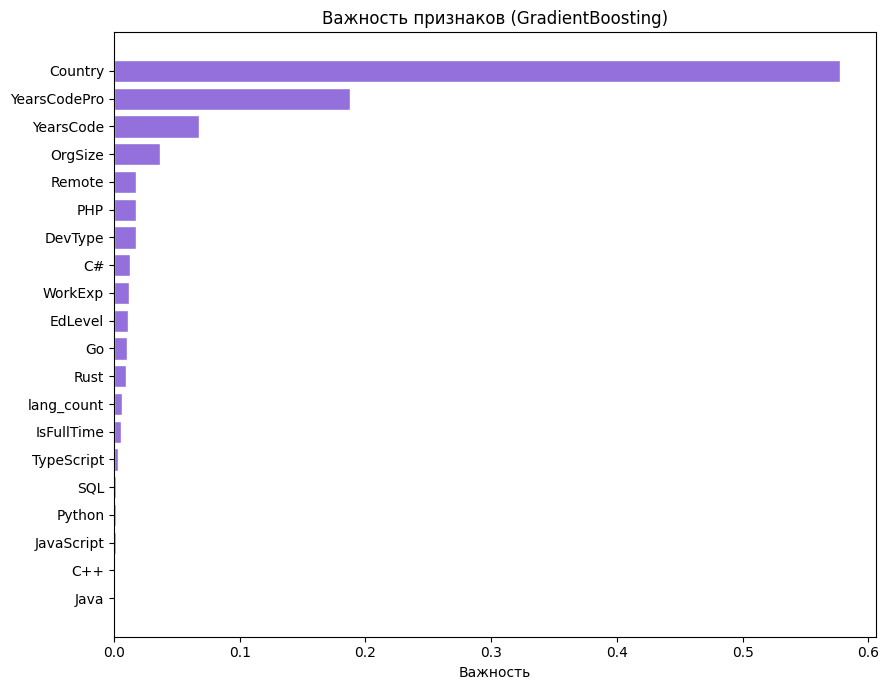

In [67]:
# Важность признаков
importances = best_model.feature_importances_
feat_labels = ['YearsCodePro', 'YearsCode', 'WorkExp',
               'EdLevel', 'OrgSize', 'Remote', 'Country', 'DevType',
               'lang_count', 'Python', 'JavaScript', 'TypeScript',
               'SQL', 'Java', 'C#', 'C++', 'PHP', 'Go', 'Rust', 'IsFullTime']

imp_df = pd.DataFrame({'Feature': feat_labels, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='mediumpurple', edgecolor='white')
ax.set_xlabel('Важность')
ax.set_title('Важность признаков (GradientBoosting)')
plt.tight_layout()
plt.show()

In [68]:
# Итоговая таблица всех моделей
all_results = []
for r in baseline_results:
    all_results.append({**r, 'Type': 'Baseline'})
for r in tuned_results:
    all_results.append({**r, 'Type': 'Tuned'})

final_df = pd.DataFrame(all_results)
final_df.sort_values(['Type', 'R2'], ascending=[True, False])

,Model,MAE,RMSE,R2,MAPE,Type
5,GradientBoosting,30965.1,46965.8,0.4941,50.77,Baseline
4,RandomForest,31949.6,47918.8,0.4733,53.17,Baseline
0,LinearRegression,38283.7,54573.0,0.3169,69.39,Baseline
1,Ridge (alpha=1),38282.2,54574.7,0.3169,69.40,Baseline
2,KNeighborsRegressor,41554.7,60032.8,0.1734,74.49,Baseline
3,DecisionTree,45403.8,68315.4,-0.0704,69.25,Baseline
11,GradientBoosting (tuned),30708.8,46696.4,0.4999,49.21,Tuned
10,RandomForest (tuned),31418.4,47501.3,0.4825,52.26,Tuned
9,DecisionTree (tuned),33498.9,49775.0,0.4317,57.49,Tuned
6,LinearRegression,38283.7,54573.0,0.3169,69.39,Tuned


## 12. Выводы

### 12.1 Сводная таблица результатов

| Модель | Тип | MAE ($) | RMSE ($) | R² | MAPE (%) |
|--------|-----|---------|---------|-----|----------|
| LinearRegression | Baseline | 38 284 | 54 573 | 0.3169 | 69.39 |
| Ridge (alpha=1) | Baseline | 38 282 | 54 575 | 0.3169 | 69.40 |
| KNeighborsRegressor | Baseline | 41 555 | 60 033 | 0.1734 | 74.49 |
| DecisionTree | Baseline | 45 404 | 68 315 | −0.0704 | 69.25 |
| RandomForest | Baseline | 31 950 | 47 919 | 0.4733 | 53.17 |
| GradientBoosting | Baseline | 30 965 | 46 966 | 0.4941 | 50.77 |
| LinearRegression | Tuned | 38 284 | 54 573 | 0.3169 | 69.39 |
| Ridge (alpha=50) | Tuned | 38 218 | 54 665 | 0.3146 | 69.79 |
| KNN (k=20, distance) | Tuned | 39 633 | 58 038 | 0.2274 | 72.49 |
| DecisionTree (depth=5) | Tuned | 33 499 | 49 775 | 0.4317 | 57.49 |
| RandomForest (n=200, depth=10) | Tuned | 31 418 | 47 501 | 0.4825 | 52.26 |
| **GradientBoosting (lr=0.1, n=200, depth=3)** | **Tuned** | **30 709** | **46 696** | **0.4999** | **49.21** |

### 12.2 Итоговые выводы

1. **Датасет.** Использован Stack Overflow Developer Survey 2024 (65 437 записей). После фильтрации по зарплате (10 000–500 000 USD) осталось 20 907 записей. Для обучения использовалось 10 000 записей, для тестирования — 3 000 (test1) и 7 907 (test2).

2. **Признаки.** Сконструировано 20 признаков: три числовых признака опыта (YearsCodePro, YearsCode, WorkExp), два порядковых (EdLevel 1–8, OrgSize 1–9), формат работы, страна (LabelEncoder, топ-10), тип разработчика, количество языков и 10 бинарных флагов языков программирования. Пропуски в числовых признаках заполнялись медианой (до 15% строк по WorkExp). Наибольшую корреляцию с зарплатой имеет признак страны (r=0.387), затем профессиональный опыт (r=0.348).

3. **Качество базовых моделей (baseline).** Ансамблевые модели без настройки показали наилучшее качество (GradientBoosting: R²=0.494, MAE=$30 965). DecisionTree с параметрами по умолчанию дал отрицательный R²=−0.070 из-за переобучения (дерево неограниченной глубины). Линейные модели показали R²=0.317, что подтверждает нелинейный характер зависимости зарплаты от признаков.

4. **Подбор гиперпараметров** (GridSearchCV, 3–5-кратная кросс-валидация) дал следующие результаты:
   - Ridge: alpha=50 → R² практически не изменился (нет мультиколлинеарности)
   - KNN: k=20, weights=distance → R²: 0.173 → 0.227
   - DecisionTree: max_depth=5 → **R²: −0.070 → 0.432** (наибольший относительный прирост)
   - RandomForest: n_estimators=200, max_depth=10 → R²: 0.473 → 0.483
   - GradientBoosting: learning_rate=0.1, n_estimators=200, max_depth=3 → **лучший результат R²=0.500**

5. **Лучшая модель — `GradientBoosting (tuned)`** с параметрами `learning_rate=0.1, n_estimators=200, max_depth=3`:
   - MAE = $30 709 (средняя ошибка предсказания)
   - RMSE = $46 696
   - R² = 0.4999
   - MAPE = 49.21%

6. **Стабильность модели.** Результаты на большей тестовой выборке (test2, 7 907 записей): MAE=$30 617, R²=0.485 — практически совпадают с результатами на test1, что свидетельствует об отсутствии переобучения.

7. **Интерпретация.** Достигнутый R²=0.50 является ожидаемым результатом для задачи предсказания зарплаты по данным самоотчёта: зарплата определяется множеством неучтённых факторов — конкретным работодателем, переговорными навыками, специализацией внутри стека, бонусами. Модель объясняет половину дисперсии зарплат и уверенно превосходит все линейные baseline-решения. Высокое значение MAPE (49%) объясняется широким диапазоном зарплат: от $10 000 (начинающий специалист в развивающейся стране) до $500 000 (senior-специалист в США).